# Starting from Raw Data

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

from Dpipe import startup, repkg, pipe
from Dpipe import timeseries_util as tsu
from Dpipe import cuts, filtering, modulator

# Verify environment
print('DPIPE_PREFIX =', os.getenv('DPIPE_PREFIX'))
print('MAPMAKING_IN =', os.getenv('MAPMAKING_IN'))
assert os.getenv('DPIPE_PREFIX'), "Set DPIPE_PREFIX before running"

DPIPE_PREFIX = /home/viviantao1/class_code
MAPMAKING_IN = /data/users/class/mapmaking_in/


can also check 56lp spans
/data/users/class/mapmaking_in/dtod/w1_band/56lp/span_info.csv


things to do:


part 1 transition points
- for each detector, find every large transition in amplitudes (store detector, span_before, span_after)
- count number of active detectors per span
- for each detector comput median_amplitude(span i+1)-median_amplitude(span i)


part 2 raw timestreams before,during,after change
look at "neighboring" detectors

In [2]:
dpipe_path = os.getenv('DPIPE_PREFIX')

#hwp_cfg = startup.DpipeConfig(os.path.join(dpipe_path, 'Dpipe/parameter_files/w1_hwp_demo.yml'))
#hwp_cfg = startup.DpipeConfig(os.path.join(dpipe_path, 'Dpipe/parameter_files/w1_hwp-8.yml'))
hwp_cfg = startup.DpipeConfig(os.path.join(dpipe_path, 'Dpipe/parameter_files/w1_56lp.v1.2+168.g2f1c7c7.dirty.yml'))
print(f"\nHWP config: recv={hwp_cfg.recv}, timeline={hwp_cfg.timeline}")
print(f"  UIDs: {hwp_cfg.uids}")


HWP config: recv=w1_band, timeline={'era4': 'w1_full'}
  UIDs: {'era4': [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 26, 29, 30, 32, 33, 44, 45, 47, 48, 49, 67, 68, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 98, 102, 103, 106, 110, 113, 114, 116, 119, 120, 121, 123, 124, 126, 127, 128, 129, 130, 132, 133, 135, 140, 141, 145, 148, 154, 156, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 170, 172, 173, 174, 177, 180, 182, 183, 204, 205, 206, 208, 209, 211, 212, 214, 215, 216, 217, 220, 223, 224, 225, 226, 228, 229, 230, 231, 233, 235, 236, 239, 242, 243, 248, 253, 255, 257, 261, 262, 263, 264, 265, 266, 267, 268, 270, 272, 277, 280, 281, 282, 287, 289, 293, 294, 295, 301, 302, 303, 304, 305, 306, 309, 313, 314, 316, 317, 319, 320, 321, 323, 324, 326, 327, 330, 331, 332, 334, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 353, 355, 356, 358, 359, 360, 361, 362, 363, 365, 367, 368, 369, 37

In [3]:
# HWP era example: February 5, 2025
hwp_t0 = datetime(2024, 11, 30, 22, 40, 0)
#hwp_t1 = datetime(2024, 8, 31, 1, 40, 0)  # 10 datapkgs
hwp_t1 = datetime(2024, 12, 1, 10, 0, 0)  # 10 datapkgs


# hwp_t0 = datetime(2024, 7, 1, 0, 0, 0)
# hwp_t1 = datetime(2025, 8, 30, 14, 0, 0)  # 10 datapkgs


print(f"\nHWP span: {hwp_t0} to {hwp_t1}")
print(f"  Expected name: {repkg.edges_to_name(hwp_t0, hwp_t1)}")


HWP span: 2024-11-30 22:40:00 to 2024-12-01 10:00:00
  Expected name: 2024-11-30-22-40-00_69


In [4]:
print("Building HWP span...")

hwp_span = repkg.Span(hwp_t0, hwp_t1, hwp_cfg)
hwp_span.load_tod(new_cache=False)

if hwp_span.kill_build:
    print("  WARNING: Span marked for kill (idle or aborted scan)")
else:
    print(f"  Span name: {hwp_span.name}")
    print(f"  Detectors: {len(hwp_span.det_uid)} ({hwp_span.det_uid})")
    print(f"  Samples: {hwp_span.tod.nsamps:,} ({hwp_span.tod.nsamps/200:.1f} sec @ 200 Hz)")
    print(f"  Grid era: {hwp_span.grid_era}")
    print(f"  Boresight: {hwp_span.bs_name}deg")

Building HWP span...
  Span name: 2024-11-30-22-40-00_69
  Detectors: 345 ([0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 26, 29, 30, 32, 33, 44, 45, 47, 48, 49, 67, 68, 70, 71, 72, 74, 75, 76, 77, 79, 80, 81, 82, 84, 85, 86, 87, 89, 90, 91, 92, 94, 95, 96, 97, 98, 102, 103, 106, 110, 113, 114, 116, 119, 120, 121, 123, 124, 126, 127, 128, 129, 130, 132, 133, 135, 140, 141, 145, 148, 154, 156, 158, 159, 160, 161, 162, 163, 164, 167, 168, 169, 170, 172, 173, 174, 177, 180, 182, 183, 204, 205, 206, 208, 209, 211, 212, 214, 215, 216, 217, 220, 223, 224, 225, 226, 228, 229, 230, 231, 233, 235, 236, 239, 242, 243, 248, 253, 255, 257, 261, 262, 263, 264, 265, 266, 267, 268, 270, 272, 277, 280, 281, 282, 287, 289, 293, 294, 295, 301, 302, 303, 304, 305, 306, 309, 313, 314, 316, 317, 319, 320, 321, 323, 324, 326, 327, 330, 331, 332, 334, 336, 337, 338, 339, 340, 341, 343, 344, 346, 348, 349, 350, 351, 353, 355, 356, 358, 359, 360, 361, 362, 363, 365, 367, 368, 369, 

In [30]:
path = '/data/field/2024-12/2024-12-05/2024-12-05-21-40-00'
tod = repkg.get_tod(path, 'w1_band')

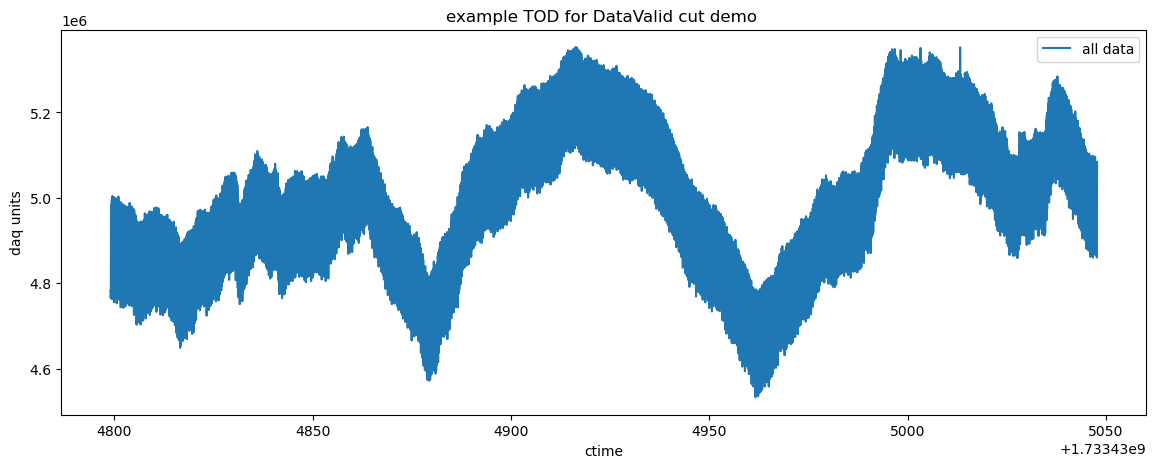

In [55]:
plt.figure(figsize=[14, 5])
plt.plot(tod.ctime[:50000], tod.data[4][:50000], label='all data')
#plt.plot(tod.ctime[~m1], tod.data[4][~m1], label='Non-cut by DataValidCut')
plt.xlabel('ctime')
plt.ylabel('daq units')
plt.title('example TOD for DataValid cut demo ')
plt.legend()

In [30]:
print(type(hwp_span.tod.det_uid))

<class 'numpy.ndarray'>


In [43]:
t_hwp = pd.to_datetime(hwp_span.tod.ctime, unit="s", utc=True)
print(t_hwp)

DatetimeIndex(['2024-11-30 22:39:59.959541760+00:00',
               '2024-11-30 22:39:59.964514304+00:00',
               '2024-11-30 22:39:59.969485824+00:00',
               '2024-11-30 22:39:59.974458112+00:00',
               '2024-11-30 22:39:59.979430656+00:00',
               '2024-11-30 22:39:59.984402432+00:00',
               '2024-11-30 22:39:59.989374976+00:00',
               '2024-11-30 22:39:59.994346496+00:00',
               '2024-11-30 22:39:59.999318528+00:00',
               '2024-11-30 22:40:00.004291072+00:00',
               ...
               '2024-12-01 10:09:59.591255040+00:00',
               '2024-12-01 10:09:59.596227328+00:00',
               '2024-12-01 10:09:59.601199616+00:00',
               '2024-12-01 10:09:59.606171392+00:00',
               '2024-12-01 10:09:59.611143936+00:00',
               '2024-12-01 10:09:59.616115968+00:00',
               '2024-12-01 10:09:59.621087488+00:00',
               '2024-12-01 10:09:59.626060032+00:00',
         

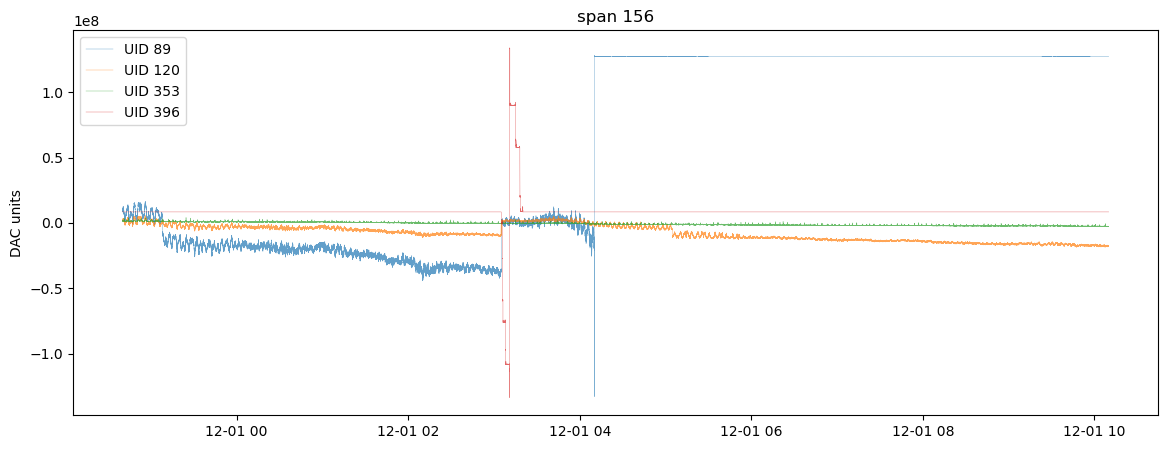

In [44]:
plt.figure(figsize=(14, 5))

#t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
#t_hwp = 
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

for i in [89, 120, 353, 396]:
    idx = np.where(hwp_span.tod.det_uid == i)[0][0]  # find index of det_uid 183

    #plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
    plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, label=f'UID {hwp_span.tod.det_uid[idx]}')

plt.ylabel('DAC units')
#plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.title("span 156")
plt.legend()

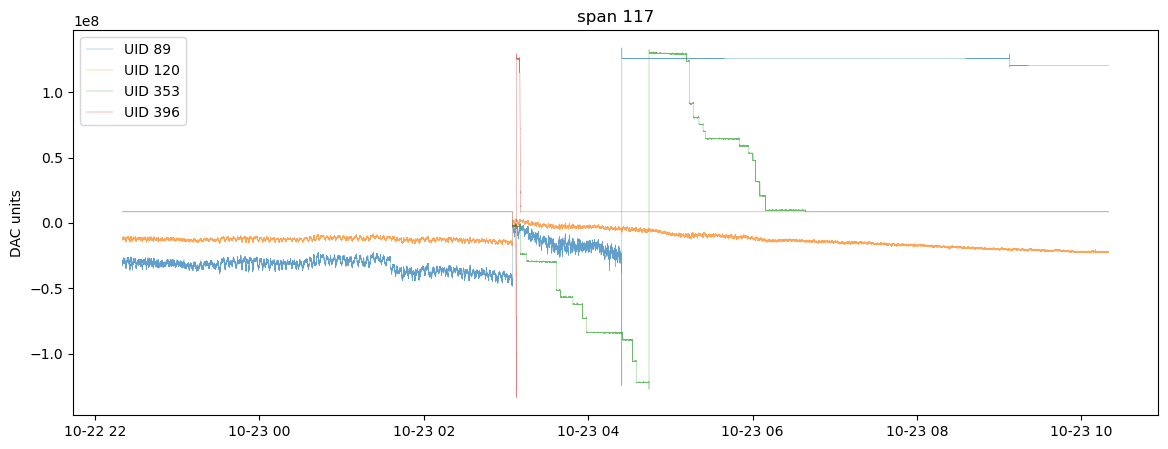

In [40]:
plt.figure(figsize=(14, 5))

#t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
#t_hwp = 
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

for i in [89, 120, 353, 396]:
    idx = np.where(hwp_span.tod.det_uid == i)[0][0]  # find index of det_uid 183

    #plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
    plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, label=f'UID {hwp_span.tod.det_uid[idx]}')

plt.ylabel('DAC units')
#plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.title("span 117")
plt.legend()

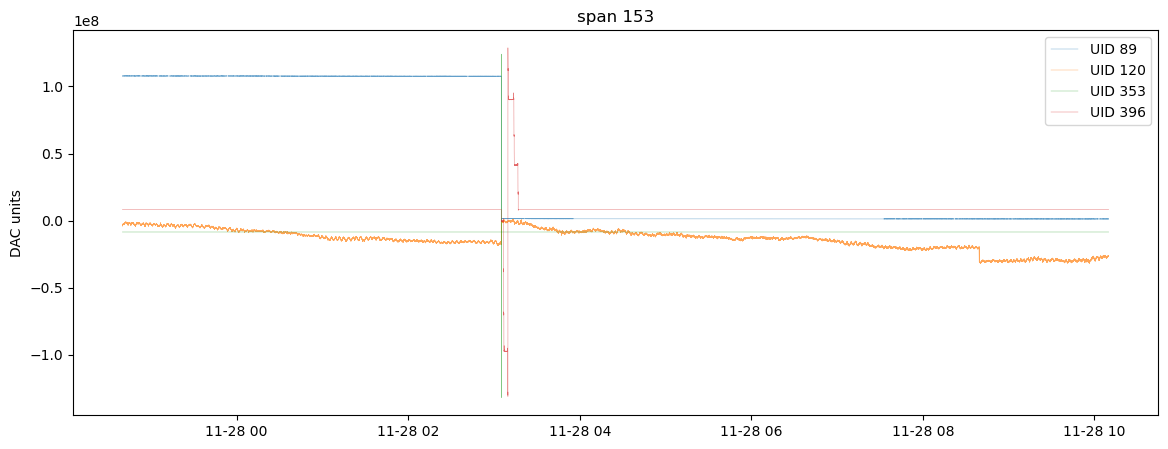

In [21]:
plt.figure(figsize=(14, 5))

#t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
#t_hwp = 
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

for i in [89, 120, 353, 396]:
    idx = np.where(hwp_span.tod.det_uid == i)[0][0]  # find index of det_uid 183

    #plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
    plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, label=f'UID {hwp_span.tod.det_uid[idx]}')

plt.ylabel('DAC units')
#plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.title("span 153")
plt.legend()

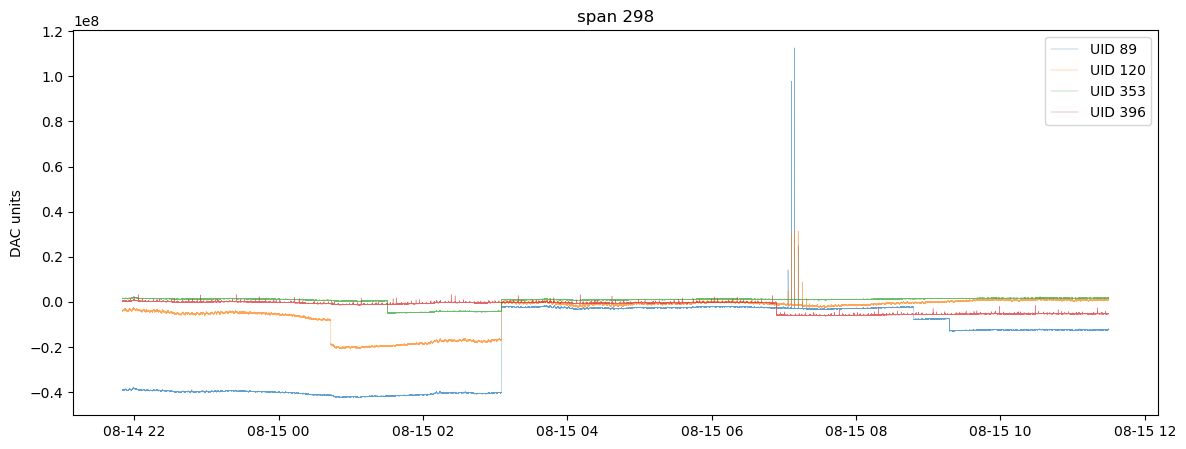

In [28]:
plt.figure(figsize=(14, 5))

#t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
#t_hwp = 
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

for i in [89, 120, 353, 396]:
    idx = np.where(hwp_span.tod.det_uid == i)[0][0]  # find index of det_uid 183

    #plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
    plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, label=f'UID {hwp_span.tod.det_uid[idx]}')

plt.ylabel('DAC units')
#plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.title("span 298")
plt.legend()

In [33]:
from Dpipe.mss_util import extract_template_from_filtered

In [7]:
print(hwp.tod.mod_freq)

NameError: name 'hwp' is not defined

In [34]:
extract_template_from_filtered??

Signature:
extract_template_from_filtered(
    filtered_data,
    encoder_data,
    modulator_type='hwp',
    mod_freq=None,
)
Source:   
def extract_template_from_filtered(filtered_data, encoder_data, modulator_type='hwp', mod_freq=None):
    """Extract a template from filtered data with proper error estimation.
    Handles both HWP and VPM data with appropriate fitting.
    VPM methods have not been tested. use with care.

    Parameters
    ----------
    filtered_data : ndarray
        Pre-filtered time-ordered data for a single detector
    encoder_data : ndarray
        Encoder values (HWP angle or VPM position)
    modulator_type : str
        'hwp' or 'vpm'
    mod_freq : float, optional
        Modulation frequency

    Returns
    -------
    dict
        Template and analysis results including error estimates
    """
    from scipy.optimize import curve_fit

    # Check for empty arrays before processing
    if len(filtered_data) == 0 or len(encoder_data) == 0:
        retur

In [32]:
extract_templates_for_time_segment??

Signature:
extract_templates_for_time_segment(
    filtered_span_data,
    start_idx,
    end_idx,
    verbose=False,
)
Source:   
def extract_templates_for_time_segment(filtered_span_data, start_idx, end_idx, verbose=False):
    """Extract templates for each detector in a time segment defined by start/end indices.

    Parameters
    ----------
    filtered_span_data : dict
        Output from filter_span_data
    start_idx : int
        Start index of segment in span's data
    end_idx : int
        End index of segment in span's data
    verbose : bool
        Whether to print progress information

    Returns
    -------
    dict
        Dictionary of template results keyed by detector UID
    """
    results = {}

    # Get span's filtered data
    filtered_data = filtered_span_data['filtered_data']
    uncut_dets = filtered_span_data['uncut_dets']
    det_uids = filtered_span_data['det_uids']
    encoder_data = filtered_span_data['encoder_data']
    modulator_type = filtered_span

In [30]:
extract_templates_from_span??

Signature: extract_templates_from_span(span, interval='dpkg', verbose=False)
Source:   
def extract_templates_from_span(span, interval='dpkg', verbose=False):
    """Extract modulation templates from all DataPkgs within a span using the given interval.

    Parameters
    ----------
    span : Span
        The Dpipe span object with loaded TOD data.
    interval : int or str
        If an integer, the number of subdivisions per data package.
        If the string 'dpkg' (case-insensitive), then use data package boundaries.
    verbose : bool
        Whether to print progress information.

    Returns
    -------
    dict
        Nested dictionary of results keyed by segment timestamp and detector UID.
    """
    results = {}

    if not hasattr(span, 'tod') or span.tod is None:
        if verbose:
            print("No TOD data found in span")
        return results

    if verbose:
        print("Filtering span data...")
    filtered_span_data = filter_span_data(span, verbose=verbose

Text(0.5, 0, 'Time (minutes)')

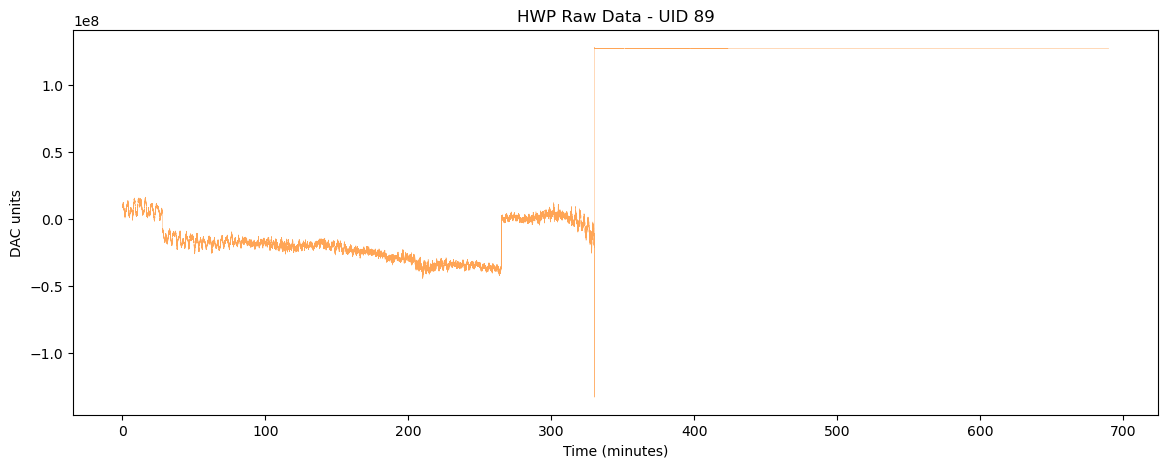

In [6]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 89)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

In [8]:
print(hwp_span.mod_freq)

2.9999986436631945


In [13]:
print(hwp_span.get_fc(hwp_span))
#print(hwp_span.set_scan_speed(hwp_span))

2.7035441377731972


# SPAN 240

Text(0.5, 0, 'Time (minutes)')

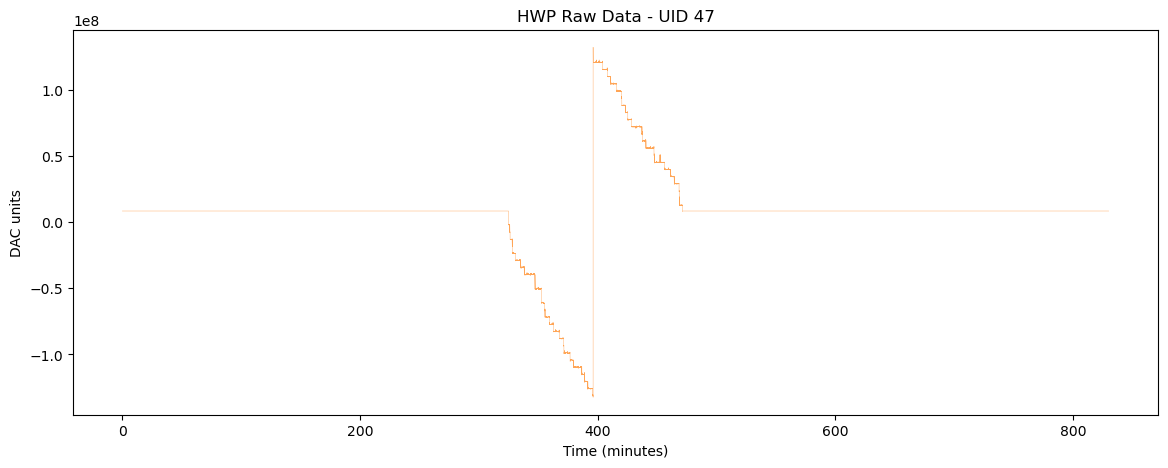

In [22]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

# SPAN 241

Text(0.5, 0, 'Time (minutes)')

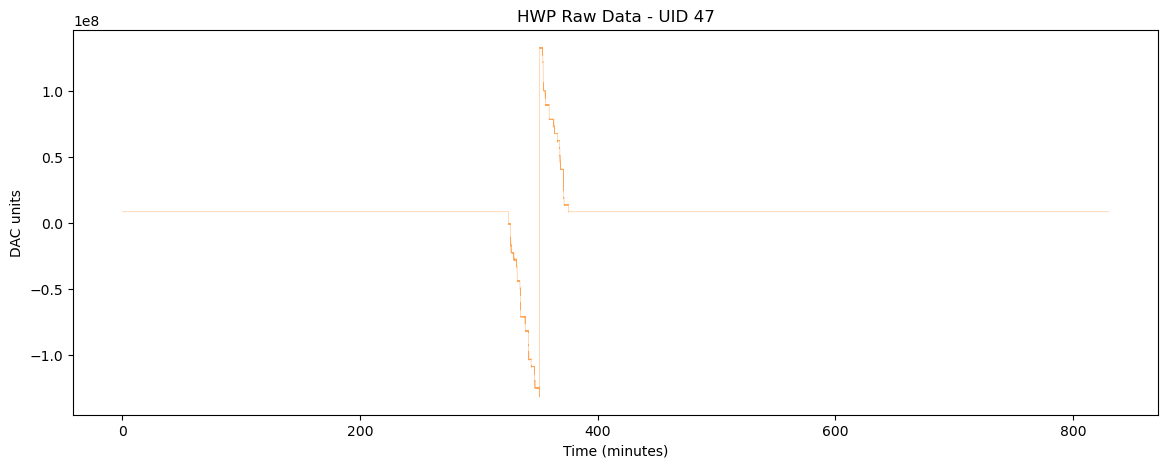

In [19]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

# SPAN 242

Text(0.5, 0, 'Time (minutes)')

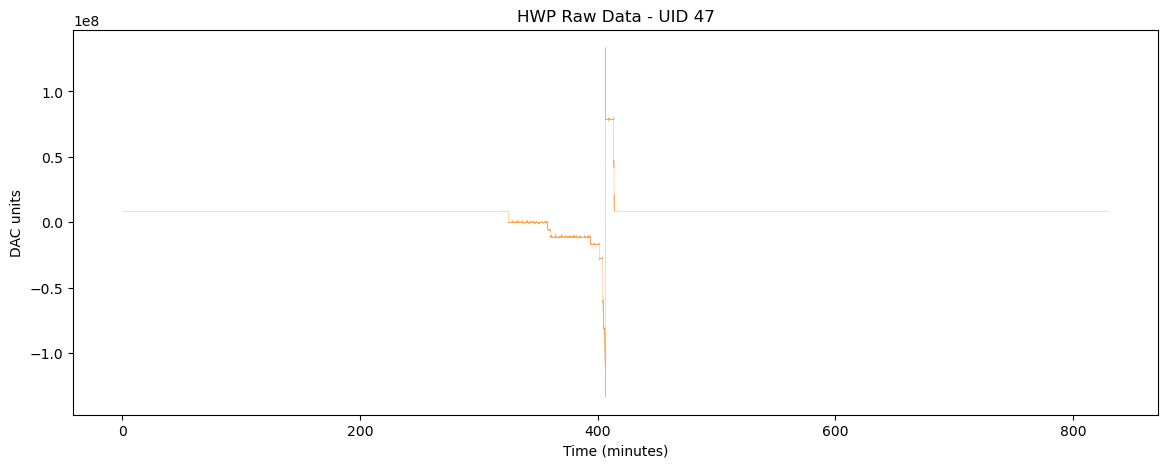

In [5]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

In [9]:
print(len(t_hwp)/8)
print(3e6)

1251975.0
3000000.0


Text(0.5, 0, 'Time (minutes)')

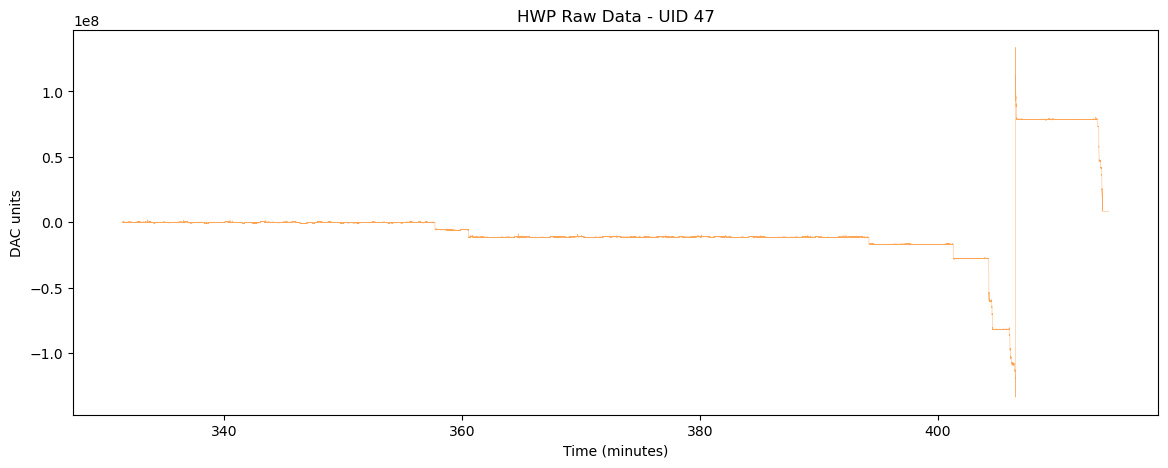

In [13]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp[int(4e6):int(5e6)], hwp_span.tod.data[idx][int(4e6):int(5e6)], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

Text(0.5, 0, 'Time (minutes)')

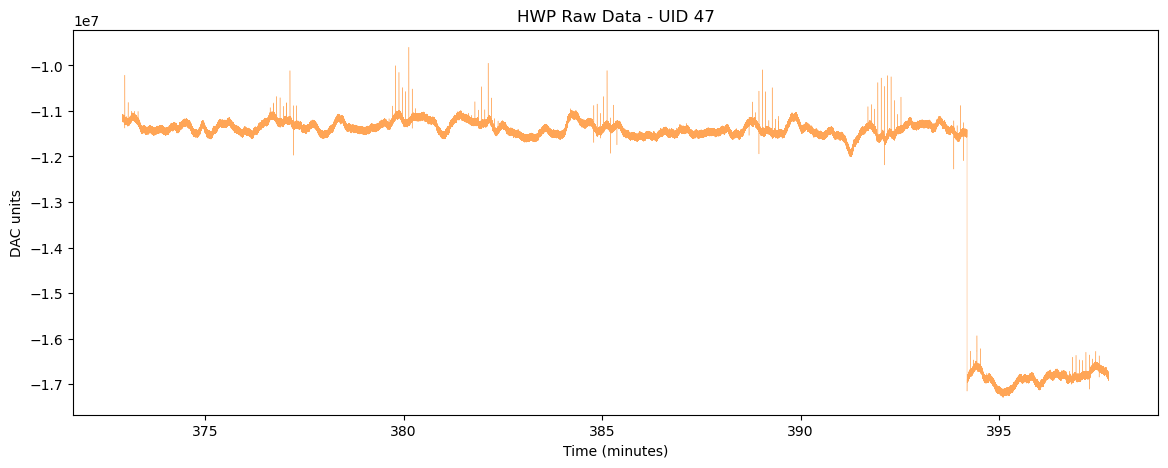

In [15]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp[int(4.5e6):int(4.8e6)], hwp_span.tod.data[idx][int(4.5e6):int(4.8e6)], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

Text(0.5, 0, 'Time (minutes)')

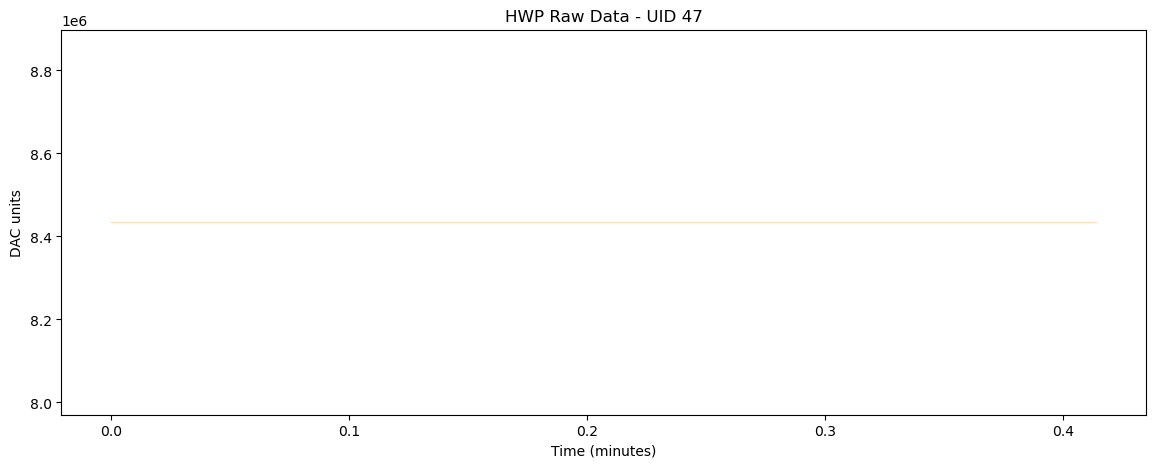

In [17]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 47)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp[:int(.005e6)], hwp_span.tod.data[idx][:int(.005e6)], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

Text(0.5, 0, 'Time (minutes)')

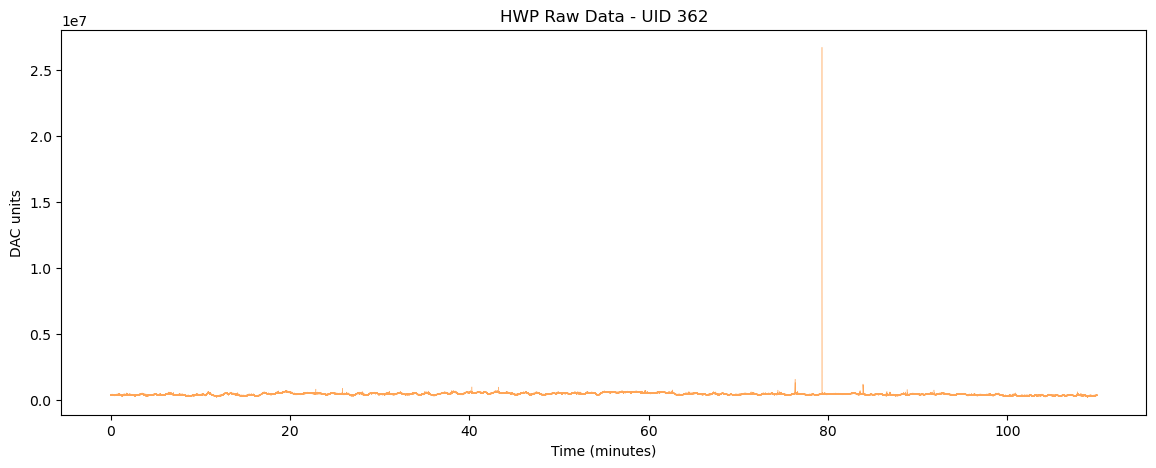

In [24]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 50 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 362)[0][0]  # find index of det_uid 183

#plt.plot(t_hwp[len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], hwp_span.tod.data[idx][len(t_hwp)-371*n_show:len(t_hwp)-370*n_show], lw=0.3, alpha=0.7, color='C1')
plt.plot(t_hwp, hwp_span.tod.data[idx], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

In [7]:
print(len(t_hwp))

1327400


Text(0.5, 0, 'Time (minutes)')

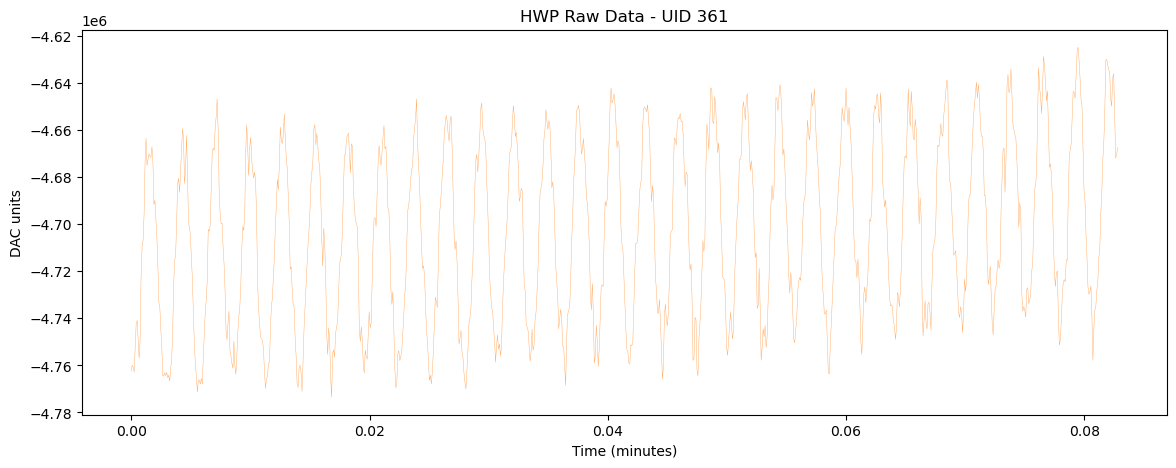

In [7]:
plt.figure(figsize=(14, 5))

t_hwp = (hwp_span.tod.ctime - hwp_span.tod.ctime[0]) / 60
n_show = 1000  # 5 seconds at 200 Hz
t_short = np.arange(n_show) / 200

idx = np.where(hwp_span.tod.det_uid == 361)[0][0]  # find index of det_uid 183

plt.plot(t_hwp[:n_show], hwp_span.tod.data[idx][:n_show], lw=0.3, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[idx]}')
plt.xlabel('Time (minutes)')

Text(0.5, 0, 'Time (sec)')

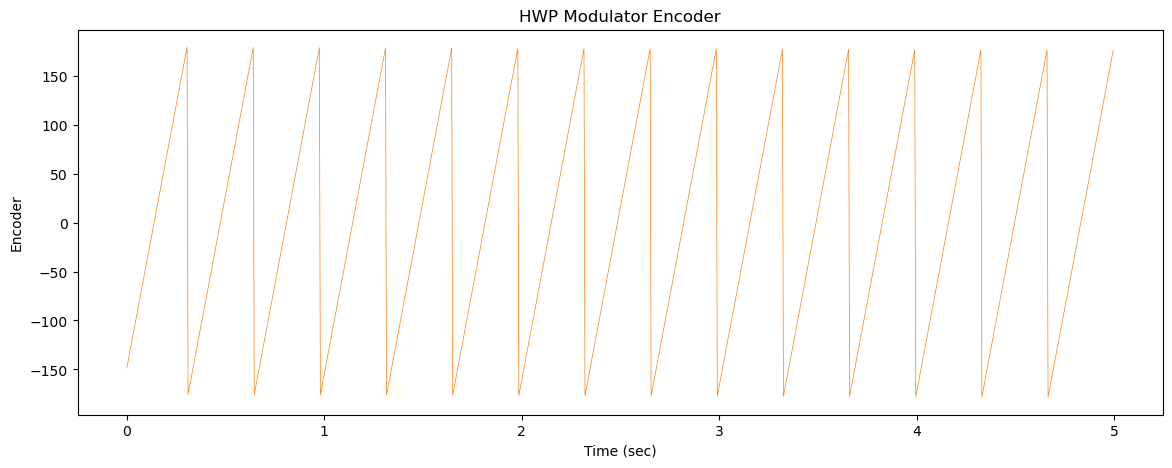

In [20]:
plt.figure(figsize=(14, 5))
n_show = 1000  # 5 seconds at 200 Hz
t_short = np.arange(n_show) / 200
plt.plot(t_short, hwp_span.tod.mod_enc[:n_show], lw=0.5, color='C1')
plt.ylabel('Encoder')
plt.title('HWP Modulator Encoder')
plt.xlabel('Time (sec)')

In [18]:
print(hwp_span.tod.data[0].shape)
print(hwp_span.tod.mod_enc.shape)
print(t_hwp.shape)
print(hwp_span.tod.mod_enc.max(), hwp_span.tod.mod_enc.min())

(1327400,)
(1327400,)
(1327400,)
179.99984741210938 -179.99972534179688


Text(0.5, 0, 'HWP Angle (degrees)')

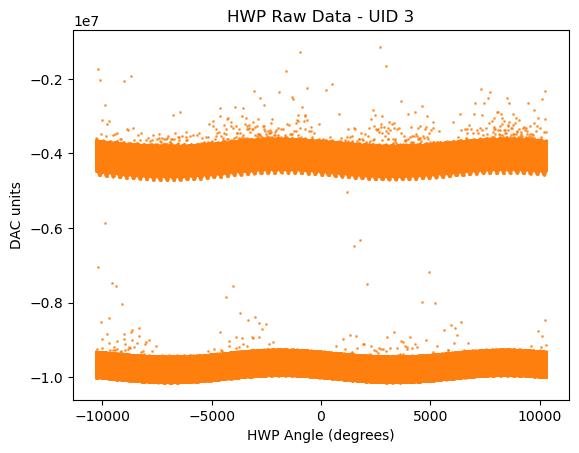

In [17]:
theta = np.degrees(hwp_span.tod.mod_enc)
plt.scatter(theta, hwp_span.tod.data[3], s=1, alpha=0.7, color='C1')
plt.ylabel('DAC units')
plt.title(f'HWP Raw Data - UID {hwp_span.tod.det_uid[3]}')
plt.xlabel('HWP Angle (degrees)')